# E59 · Counting steps you cannot see: how kinesin walks, step detection, and the hidden chemistry in dwell times

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: kinesin-1 walking on microtubules, tracked with MINFLUX at nanometre / sub-millisecond resolution (Wolff, Scheiderer et al. 2023; Zenodo, CC BY 4.0): the authors' tables of about 19,000 detected steps and dwell times (12 construct × ATP conditions) and 30 raw position traces of a dye on the motor's stalk at 10 µM and 1 mM ATP. Sections 3-4 use simulated traces at the same scales (8.2 nm steps, 2 nm noise, 2 ms samples) so that the true steps are known |
| **You will learn** | How a two-headed motor walks **hand over hand**, and why a staircase in position hides a **chemical cycle** · dwell times as **sums of exponential waits**: the **hypoexponential** distribution, the Erlang special case, and the **randomness parameter** $r = \mathrm{var}/\mathrm{mean}^2$ with the bound $n \ge 1/r$ · **step detection**: a penalised least-squares (χ²) step finder versus a Bayesian **hidden Markov model on a lattice** of positions, with hidden chemical sub-states, back-steps and correlated noise, written as a forward algorithm in `scan` · how **missed and false steps bias** dwell statistics (merged dwells look *more* regular, so you count too many hidden steps) · **label switching**: the hypoexponential is symmetric in its rates, so the rates need an ordering · model comparison by **LOO over the number of hidden steps**, and why the answer hides below the detector's **dead time** (a detector that misses short dwells is indistinguishable from one more hidden step) · a joint **ATP-titration** model (Michaelis-Menten from $k_{\text{on}}[\text{ATP}]$ in series with ATP-independent steps) with **molecule-to-molecule variation**, and how that variation can swallow the ATP effect |

## How a molecule walks

Inside every cell, cargo is carried along protein cables by motor proteins. **Kinesin-1** walks
towards the plus end of microtubules, the hollow tubes built from tubulin dimers spaced 8.2 nm
apart. It has two identical heads joined by a coiled-coil stalk. Each head binds the microtubule,
binds and splits ATP, and changes shape; the two heads take turns, the rear head swinging past the
bound one to the next binding site 16 nm ahead. The stalk, halfway between the heads, therefore
moves **8 nm per ATP**: this is the "hand-over-hand" walk (8 nm steps: Svoboda, Schmidt, Schnapp &
Block 1993; one ATP per step: Schnitzer & Block 1997; hand over hand: Yildiz, Tomishige, Vale &
Selvin 2004). Myosin V does the same on actin with 36 nm steps (Yildiz et al. 2003).

If you could watch one motor, its position would be a **staircase**: long flat dwells, then a jump
of 8 nm. Optical traps (a bead held by a laser and attached to the motor) and single-dye tracking
do exactly that. The position shows only the steps. Everything else - ATP binding, hydrolysis, a
head letting go, the neck linker zippering - happens during the flat dwell and is invisible. But
not without trace: if the dwell is the sum of several waits, each exponential, the dwell-time
**distribution** has a shape that reveals how many hidden waits there are and which of them
depends on ATP. This notebook is about reading that shape honestly: finding the steps in a noisy
trace, knowing what the step finder does to the dwell times, and fitting kinetic models to them
with PyMC.

## The plan

1. Waiting times that add up: the hypoexponential and the randomness parameter
2. Finding steps: a step finder and a hidden Markov model on a lattice (simulated traces)
3. What missed and false steps do to the dwell times
4. Data: kinesin-1 under MINFLUX
5. How many hidden steps? LOO, label switching and the detector's dead time
6. ATP titration: a Michaelis-Menten cycle, and molecules that differ

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from scipy import stats
from scipy.optimize import minimize

from pymc_challenges import data

RANDOM_SEED = 59
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
plt.rcParams["axes.titlesize"] = 11
logging.getLogger("pymc").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="The effect of Potentials")
warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED, INK = (
    "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e", "#222222")
JAX = {"backend": "jax", "gradient_backend": "jax"}
STEP = 8.2                                           # tubulin dimer spacing (nm)
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def report(idata, var_names, label, t_fit=None):
    """Print time, divergences and the worst r_hat / bulk ESS of the named variables."""
    s = az.summary(idata, var_names=var_names, round_to=4)
    div = int(idata.sample_stats["diverging"].sum())
    tt = f"{t_fit:.0f} s, " if t_fit is not None else ""
    print(f"{label}: {tt}{div} divergences, max r_hat {s['r_hat'].max():.3f}, "
          f"min ESS {s['ess_bulk'].min():.0f}")
    return s

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


## 1 · Waiting times that add up: the hypoexponential and the randomness parameter

Suppose one step of the motor needs $n$ chemical transitions in sequence, each irreversible and
memoryless with rate $k_i$. The wait for transition $i$ is exponential, $\tau_i \sim
\text{Exp}(k_i)$, and the dwell is their sum $\tau = \tau_1 + \dots + \tau_n$. Its density is the
**hypoexponential**: for distinct rates

$$f(t) = \sum_{i=1}^{n} c_i\, k_i e^{-k_i t}, \qquad c_i = \prod_{j \ne i} \frac{k_j}{k_j - k_i},
\qquad S(t) = P(\tau > t) = \sum_i c_i e^{-k_i t}.$$

With all rates equal it becomes the **Erlang** (a gamma with integer shape $n$). Three facts carry
the rest of the notebook.

- **A rise at short times.** With one step, the most likely dwell is zero. With two or more the
  density starts at $f(0) = 0$ and rises: you cannot finish a sequence of waits instantly.
- **The randomness parameter.** Mean and variance add, $\langle\tau\rangle = \sum 1/k_i$ and
  $\mathrm{var}\,\tau = \sum 1/k_i^2$, so
  $$r = \frac{\mathrm{var}\,\tau}{\langle\tau\rangle^2} = \frac{\sum_i k_i^{-2}}{\left(\sum_i k_i^{-1}\right)^2} \;\ge\; \frac{1}{n},$$
  with equality when all rates are equal. A measured $r$ therefore gives a **lower bound on the
  number of rate-limiting steps**, $n \ge 1/r$ (Svoboda, Mitra & Block 1994; Schnitzer & Block
  1995; among all phase-type distributions with $n$ phases the Erlang is the least variable:
  Aldous & Shepp 1987). One slow step and several fast ones give $r \approx 1$: fast steps are
  invisible.
- **The order of the rates is not identified.** The sum does not care which wait came first:
  $f$ is symmetric in $(k_1, \dots, k_n)$. A model with free rates has $n!$ identical modes, the
  same **label switching** as a mixture model; we will order the rates.

Dwells are not the only fluctuation: branched schemes (a back step, a futile hydrolysis) and
reversible transitions give other shapes and $r$ can exceed 1, for instance when several molecules
with different speeds are pooled - a point that will matter in section 6.

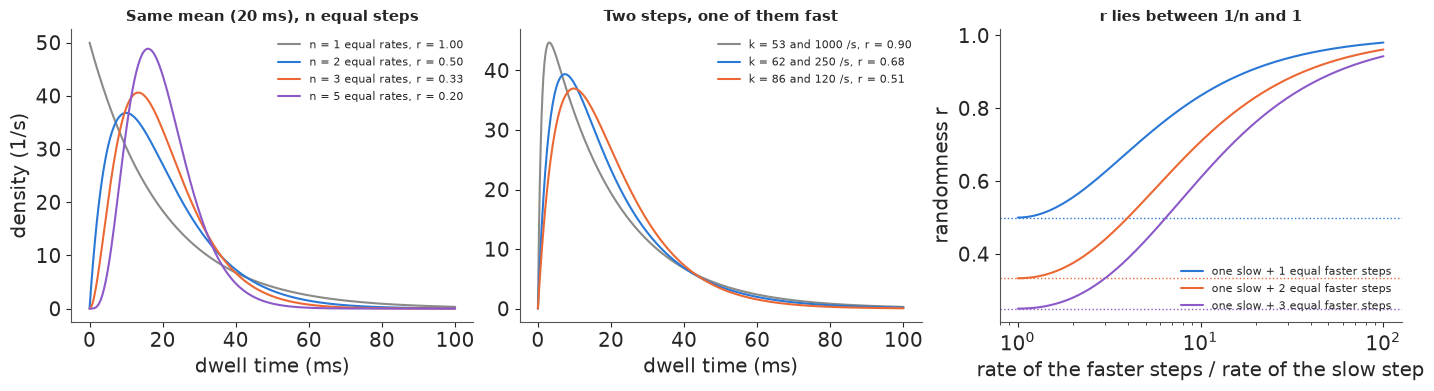

In [2]:
def np_hypo_pdf(t, k):
    """Hypoexponential density for distinct rates k (NumPy)."""
    k = np.asarray(k, float)
    c = np.array([np.prod([k[j] / (k[j] - k[i]) for j in range(len(k)) if j != i]) for i in range(len(k))])
    return (c * k * np.exp(-np.outer(t, k))).sum(-1)


def randomness(k):
    k = np.asarray(k, float)
    return np.sum(k**-2.0) / np.sum(k**-1.0) ** 2


tg = np.linspace(0, 0.1, 400)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
ax = axes[0]
for n, col in zip([1, 2, 3, 5], [GREY, BLUE, ORANGE, PURPLE]):
    k = np.full(n, n / 0.02)                                   # n equal rates, mean 20 ms: Erlang
    ax.plot(tg * 1e3, stats.gamma.pdf(tg, n, scale=1 / k[0]), color=col,
            label=f"n = {n} equal rates, r = {randomness(k):.2f}")
ax.set(xlabel="dwell time (ms)", ylabel="density (1/s)", title="Same mean (20 ms), n equal steps")
ax.legend(fontsize=8)
ax = axes[1]
for kf, col in zip([1000.0, 250.0, 120.0], [GREY, BLUE, ORANGE]):
    k = np.array([1 / (0.02 - 1 / kf), kf])
    ax.plot(tg * 1e3, np_hypo_pdf(tg, k), color=col,
            label=f"k = {k[0]:.0f} and {kf:.0f} /s, r = {randomness(k):.2f}")
ax.set(xlabel="dwell time (ms)", title="Two steps, one of them fast")
ax.legend(fontsize=8)
ax = axes[2]
ratio = np.geomspace(1, 100, 200)
for n, col in zip([2, 3, 4], [BLUE, ORANGE, PURPLE]):
    rr = [randomness(np.r_[1.0, np.full(n - 1, q)]) for q in ratio]
    ax.plot(ratio, rr, color=col, label=f"one slow + {n - 1} equal faster steps")
    ax.axhline(1 / n, color=col, ls=":", lw=1)
ax.set(xscale="log", xlabel="rate of the faster steps / rate of the slow step", ylabel="randomness r",
       title="r lies between 1/n and 1")
ax.legend(fontsize=8);

Left: at the same mean dwell, more equal hidden steps make the distribution narrower and push its
peak away from zero; $r$ falls as $1/n$. Middle: two steps with the same 20 ms mean, one of them
fast. With the second step at 1,000/s the curve is almost a plain exponential ($r = 0.90$); only
the first few milliseconds of the distribution carry the evidence that a second step exists.
Right: $r$ lies between $1/n$ (dotted lines, all rates equal) and 1 (one step much slower than the
rest). This is why $1/r$ is only a lower bound on the number of steps, and why the shortest dwells
matter most - the ones a step finder is worst at.

## 2 · Finding steps: a step finder and a hidden Markov model on a lattice

Before any of this we need the dwells, which means finding the steps in a noisy position trace. We
simulate traces at the scale of the MINFLUX data of section 4 so that the truth is known:

- the motor waits in chemical state A (rate $k_1 = 45$/s, think "waiting for ATP at ~10 µM"),
  moves to state B, and steps forward by $d = 8.2$ nm with rate $k_2 = 90$/s; from A it can also
  step **backwards** at $k_b = 1$/s. The true dwells are hypoexponential with $r = 0.56$;
- positions are recorded every 2 ms with noise of sd $\sigma = 2$ nm that is **correlated** from
  sample to sample (an AR(1) / discretised Ornstein-Uhlenbeck process with lag-1 correlation $\phi
  = 0.45$). This is the situation of an optical trap, where the bead relaxes in the trap with a
  finite time constant and the signal is low-pass filtered before sampling. (The MINFLUX traces of
  section 4 turn out to have almost uncorrelated noise; the correlation here is a stress test for
  the step finder.)

**The step finder.** A classic approach fits a piecewise-constant function by least squares and
adds a penalty $\beta$ per step, so a step is kept only if it lowers the squared error by more
than $\beta$ (this is the idea behind the χ²-based step finder of Kerssemakers et al. 2006 and its
successors such as AutoStepfinder, Loeff et al. 2021; MATLAB's `ischange`, which the MINFLUX
authors used, minimises the same penalised criterion). With $\beta = 12\hat\sigma^2$ and the noise
estimated from successive differences, $\hat\sigma = \mathrm{sd}(\Delta y)/\sqrt 2$ (the authors'
choice), we solve it exactly by dynamic programming ("optimal partitioning", $O(T^2)$).

**The hidden Markov model.** A generative model of the trace instead. The hidden state is (site
$m$ on the 8.2 nm lattice, chemical phase $j \in \{A, B\}$): the lattice makes the step size a
parameter shared by all steps instead of one free height per step, and the phases make the dwell
hypoexponential. Per sample of length $\Delta t$ the transitions are A → B with probability $p_1 =
(1 - e^{-(k_1 + k_b)\Delta t})\,k_1/(k_1 + k_b)$, A → (site $m-1$, A) with the $k_b$ share, and B
→ (site $m+1$, A) with $p_2 = 1 - e^{-k_2 \Delta t}$ (at most one transition per sample, fine when
$k\Delta t \ll 1$). The observation is

$$y_t = x_0 + d\,(m_t - m_0) + e_t, \qquad e_t = \phi\, e_{t-1} + \sqrt{1 - \phi^2}\,\sigma\,\varepsilon_t,$$

so the emission depends on the pair (previous site, current site), which the forward algorithm
handles by treating "stayed", "stepped forward" and "stepped back" separately. The forward
recursion runs over time in `pytensor.scan` for a batch of traces at once, with the hidden states
summed out exactly; the rates are **ordered** ($k_{\text{slow}} < k_{\text{fast}}$) because the
two phases are exchangeable in the likelihood. Viterbi decoding of the fitted model then gives the
steps.

In [3]:
def simulate_trace(rng, T, dt, d, sigma, phi, k1, k2, kb, m0=4):
    """Continuous-time two-phase stepper sampled every dt, AR(1) noise. Returns
    (t, y, site at each sample, true step times, step directions)."""
    tmax, t, site, phase, times, dirs = T * dt, 0.0, m0, 0, [], []
    while True:
        rate = k1 + kb if phase == 0 else k2
        t += rng.exponential(1 / rate)
        if t > tmax:
            break
        if phase == 1:
            phase, site = 0, site + 1
            times.append(t); dirs.append(1)
        elif rng.random() < k1 / rate:
            phase = 1
        else:
            site -= 1
            times.append(t); dirs.append(-1)
    ts = np.arange(T) * dt
    times, dirs = np.array(times), np.array(dirs, int)
    path = m0 + np.array([dirs[times <= s].sum() for s in ts])
    e = np.empty(T)
    e[0] = rng.normal(0, sigma)
    for i in range(1, T):
        e[i] = phi * e[i - 1] + rng.normal(0, sigma * np.sqrt(1 - phi**2))
    return ts, d * (path - m0) + e, path, times, dirs


def step_finder(x, beta):
    """Exact penalised least squares (optimal partitioning): change points and the fitted staircase."""
    n = len(x)
    c1, c2 = np.r_[0, np.cumsum(x)], np.r_[0, np.cumsum(x**2)]
    F, last = np.full(n + 1, np.inf), np.zeros(n + 1, int)
    F[0] = -beta
    for e in range(1, n + 1):
        s = np.arange(e)
        v = F[s] + c2[e] - c2[s] - (c1[e] - c1[s]) ** 2 / (e - s) + beta
        last[e] = np.argmin(v)
        F[e] = v[last[e]]
    cps, e = [], n
    while e > 0:
        cps.append(last[e]); e = last[e]
    cps = sorted(cps)[1:]
    fit, b = np.empty(n), [0] + cps + [n]
    for a, c in zip(b[:-1], b[1:]):
        fit[a:c] = x[a:c].mean()
    return np.array(cps, int), fit


def pad_traces(traces):
    """Stack ragged traces into (T, n) arrays; MASK = 0 marks padding."""
    n, T = len(traces), max(len(x) for _, x in traces)
    Y, DT, MASK = np.zeros((T, n)), np.full((T, n), 1e-3), np.zeros((T, n))
    for j, (t, x) in enumerate(traces):
        Y[:len(x), j], DT[1:len(x), j], MASK[:len(x), j] = x, np.diff(t), 1
    return Y, DT, MASK


def lattice_hmm_loglik(Y, DT, MASK, x0, d, sigma, phi, k1, k2, kb, M, m0):
    """Log-likelihood of each trace under the two-phase lattice HMM (forward algorithm in scan).
    alpha has shape (traces, M sites, 2 phases) and is renormalised at every step."""
    n = Y.shape[1]
    mu = x0[:, None] + d * (pt.arange(M) - m0)[None, :]
    le0 = -0.5 * ((Y[0] - mu[:, m0]) / sigma) ** 2 - pt.log(sigma) - 0.5 * np.log(2 * np.pi)
    a0 = pt.set_subtensor(pt.zeros((n, M, 2))[:, m0, 0], 1.0)
    se = sigma * pt.sqrt(1 - phi**2)                          # innovation sd of the AR(1) noise

    def step(y, yp, dt, mask, a, mu, d, se, phi, k1, k2, kb):
        q0 = -pt.expm1(-(k1 + kb) * dt)[:, None]               # leave phase A (forward or back)
        p1, pb = q0 * k1 / (k1 + kb), q0 * kb / (k1 + kb)
        p2 = -pt.expm1(-k2 * dt)[:, None]
        z = y[:, None] - mu - phi * (yp[:, None] - mu)          # residual if the site did not change
        lst = -0.5 * (z / se) ** 2
        lfw = -0.5 * ((z - phi * d) / se) ** 2                  # came from site m - 1
        lbk = -0.5 * ((z + phi * d) / se) ** 2                  # came from site m + 1
        occ = pt.log(a.sum(-1) + 1e-300)                        # scale factor: best reachable emission
        occ_prev = pt.concatenate([pt.full((n, 1), -1e300), occ[:, :-1]], axis=1)
        occ_next = pt.concatenate([occ[:, 1:], pt.full((n, 1), -1e300)], axis=1)
        mx = pt.max(pt.maximum(lst + occ, pt.maximum(lfw + occ_prev, lbk + occ_next)), axis=1, keepdims=True)
        mx = pytensor.gradient.disconnected_grad(mx)
        live = mask[:, None] > 0
        est, efw, ebk = [pt.switch(live, pt.exp(pt.minimum(l - mx, 60.0)), 1.0) for l in (lst, lfw, lbk)]
        A, B = a[:, :, 0], a[:, :, 1]
        B_prev = pt.concatenate([pt.zeros((n, 1)), B[:, :-1]], axis=1)
        A_next = pt.concatenate([A[:, 1:], pt.zeros((n, 1))], axis=1)
        newA = A * (1 - p1 - pb) * est + B_prev * p2 * efw + A_next * pb * ebk
        newB = B * (1 - p2) * est + A * p1 * est
        new = pt.stack([newA, newB], axis=-1)
        c = pt.maximum(new.sum(axis=(1, 2)), 1e-300)
        ll = pt.log(c) + mx[:, 0] - pt.log(se) - 0.5 * np.log(2 * np.pi)
        return pt.switch(mask[:, None, None] > 0, new / c[:, None, None], a), pt.switch(mask > 0, ll, 0.0)

    _, lls = pytensor.scan(step, sequences=[pt.as_tensor(Y[1:]), pt.as_tensor(Y[:-1]), pt.as_tensor(DT[1:]),
                                            pt.as_tensor(MASK[1:])],
                           outputs_info=[a0, None], non_sequences=[mu, d, se, phi, k1, k2, kb],
                           return_updates=False)
    return le0 + lls.sum(axis=0)


def viterbi(t, x, x0, d, sigma, phi, k1, k2, kb, M, m0):
    """Most probable (site, phase) path of one trace under the lattice HMM (NumPy)."""
    T, dt = len(x), np.r_[1e-3, np.diff(t)]
    mu, se, ms, NEG = x0 + d * (np.arange(M) - m0), sigma * np.sqrt(1 - phi**2), np.arange(M), -1e300
    V = np.full((M, 2), NEG)
    V[m0, 0] = 0.0
    back = np.zeros((T, M, 2, 2), int)
    for s in range(1, T):
        q0 = -np.expm1(-(k1 + kb) * dt[s])
        lp1, lpb, lp2 = np.log(q0 * k1 / (k1 + kb)), np.log(q0 * kb / (k1 + kb)), np.log(-np.expm1(-k2 * dt[s]))
        e = lambda prev: -0.5 * ((x[s] - mu - phi * (x[s - 1] - prev)) / se) ** 2
        est, efw, ebk = e(mu), e(mu - d), e(mu + d)
        cA = np.stack([V[:, 0] - (k1 + kb) * dt[s] + est, np.r_[NEG, V[:-1, 1]] + lp2 + efw,
                       np.r_[V[1:, 0], NEG] + lpb + ebk])
        cB = np.stack([V[:, 1] - k2 * dt[s] + est, V[:, 0] + lp1 + est])
        iA, iB = cA.argmax(0), cB.argmax(0)
        back[s, :, 0, 0] = np.choose(iA, [ms, np.maximum(ms - 1, 0), np.minimum(ms + 1, M - 1)])
        back[s, :, 0, 1] = np.choose(iA, [0, 1, 0])
        back[s, :, 1, 0], back[s, :, 1, 1] = ms, np.choose(iB, [1, 0])
        V = np.stack([cA.max(0), cB.max(0)], -1)
    m, j = np.unravel_index(np.argmax(V), V.shape)
    path = np.zeros((T, 2), int)
    path[-1] = m, j
    for s in range(T - 1, 0, -1):
        m, j = back[s, m, j]
        path[s - 1] = m, j
    return path


SIM = dict(d=STEP, sigma=2.0, phi=0.45, k1=45.0, k2=90.0, kb=1.0)
DT_SIM, T_SIM, N_SIM = 0.002, 300, 12
sims = [simulate_trace(rng, T_SIM, DT_SIM, **SIM) for _ in range(N_SIM)]
true_dw = np.concatenate([np.diff(s[3][s[4] > 0]) for s in sims])
print(f"{N_SIM} traces of {T_SIM * DT_SIM:.1f} s, {sum(len(s[3]) for s in sims)} true steps "
      f"({sum((s[4] < 0).sum() for s in sims)} backward); true dwells between forward steps: "
      f"mean {1e3 * true_dw.mean():.1f} ms, r = {true_dw.var() / true_dw.mean()**2:.2f}")
mle = minimize(lambda p: -np.log(np_hypo_pdf(true_dw, np.sort(np.exp(p)) * [1, 1.001])).sum(),
               np.log([40.0, 120.0]), method="Nelder-Mead")
print("maximum-likelihood rates from the exact true dwells:", np.round(np.sort(np.exp(mle.x)), 0))

12 traces of 0.6 s, 223 true steps (8 backward); true dwells between forward steps: mean 31.2 ms, r = 0.59
maximum-likelihood rates from the exact true dwells: [ 43. 124.]


Twelve short traces, about 220 steps. Now the Bayesian lattice HMM. Priors: the step size $d \sim
N(8, 3)$ nm (wide: the lattice spacing is learned, not imposed), $\sigma \sim
\text{LogNormal}(\log 2, 0.5)$ nm, $\phi \sim U(-0.5, 0.95)$, log-rates $\sim N(\log 50, 1.5)$
with the ordered transform, a back-step rate $k_b \sim \text{LogNormal}(\log 2, 1)$/s and one
offset $x_0$ per trace.

Two practical points. Each gradient runs a 300-step `scan` over 12 traces × ~30 sites × 2 phases;
under PyTensor's JAX backend that costs several milliseconds, so we draw 400 samples per chain
(enough for six parameters, see the ESS below; the fit takes one to two minutes). And the posterior of a
lattice model is **multimodal**: in a pilot run on a smaller simulated data set, two of four
chains started by nutpie's random jitter settled in a mode where larger, more correlated noise
($\sigma \approx 2.5$-$2.7$ nm, $\phi \approx 0.65$-$0.7$) absorbs some of the steps. We start all
chains from the same sensible point without jitter (`jitter_rvs=set()`) and check afterwards that
no chain wandered.

In [4]:
Y, DTm, MASK = pad_traces([(s[0], s[1]) for s in sims])
M_SIM, M0 = int(max(s[2].max() for s in sims)) + 6, 4

with pm.Model() as hmm_model:
    d = pm.Normal("d", 8.0, 3.0)
    sigma = pm.LogNormal("sigma", np.log(2.0), 0.5)
    phi = pm.Uniform("phi", -0.5, 0.95)
    log_k = pm.Normal("log_k", np.log(50.0), 1.5, shape=2, transform=pm.distributions.transforms.ordered)
    k_slow = pm.Deterministic("k_slow", pt.exp(log_k[0]))
    k_fast = pm.Deterministic("k_fast", pt.exp(log_k[1]))
    k_back = pm.LogNormal("k_back", np.log(2.0), 1.0)
    x0 = pm.Normal("x0", 0.0, 4.0, shape=N_SIM)
    pm.Potential("trace_loglik", lattice_hmm_loglik(Y, DTm, MASK, x0, d, sigma, phi, k_slow, k_fast, k_back,
                                                    M_SIM, M0).sum())
    t0 = time.time()
    idata_hmm = pm.sample(draws=400, random_seed=RANDOM_SEED, progressbar=False,
                          initvals={"d": 8.0, "sigma": 1.5, "phi": 0.2, "log_k": np.log([30.0, 150.0]),
                                    "k_back": 1.0},
                          compile_kwargs={**JAX, "jitter_rvs": set()})
    t_hmm = time.time() - t0

HMM_VARS = ["d", "sigma", "phi", "k_slow", "k_fast", "k_back"]
s_hmm = report(idata_hmm, HMM_VARS, "lattice HMM", t_hmm)
s_hmm["truth"] = [SIM["d"], SIM["sigma"], SIM["phi"], SIM["k1"], SIM["k2"], SIM["kb"]]
print(s_hmm[["mean", "sd", "eti89_lb", "eti89_ub", "truth"]].round(3))
print("per-chain means of sigma:", idata_hmm.posterior["sigma"].mean("draw").values.round(3))

lattice HMM: 128 s, 0 divergences, max r_hat 1.008, min ESS 667
           mean       sd  eti89_lb  eti89_ub  truth
d         8.196    0.010     8.180     8.212   8.20
sigma     1.996    0.029     1.951     2.043   2.00
phi       0.440    0.015     0.415     0.464   0.45
k_slow   38.944    3.872    33.402    45.493  45.00
k_fast  212.723  123.172   116.697   358.782  90.00
k_back    1.351    0.464     0.719     2.120   1.00
per-chain means of sigma: [1.996 1.995 1.998 1.995]


The HMM recovers the observation model almost exactly: step size, noise sd and noise correlation
are within a few hundredths of the truth with tight intervals, and the back-step rate is about
right (8 back steps in the data). The kinetics are harder. The slow rate comes out at ~39/s with
the truth (45/s) at the upper edge of its 89% interval, and the fast rate is poorly determined:
its interval (roughly 120-360/s) excludes the true 90/s. That is not a failure of the HMM. The
dwells actually realised in this simulation are more exponential than their distribution ($r =
0.59$ against 0.56), and a maximum-likelihood fit to those *exact* true dwells, with no noise at
all, gives 43 and 124/s (printed under the simulation cell). About 200 dwells carry little
information about a second, faster step - the lesson of section 1's middle panel. Next, the
decoded steps.

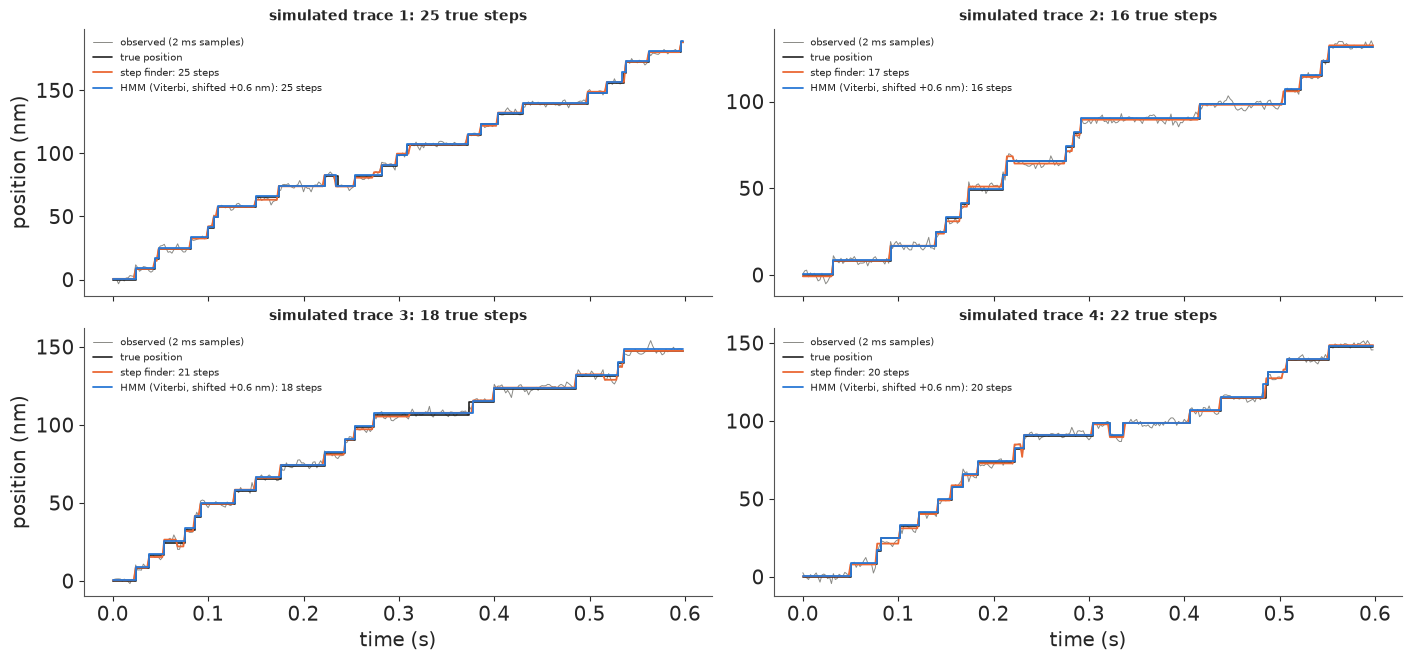

In [5]:
post = {v: float(idata_hmm.posterior[v].mean()) for v in HMM_VARS}
x0_hat = idata_hmm.posterior["x0"].mean(("chain", "draw")).values


def detect_all(t, y, x0, pars, sigma_for_penalty=None):
    """Step times (s) found by the penalised step finder and by Viterbi decoding of the HMM."""
    sig = np.std(np.diff(y)) / np.sqrt(2) if sigma_for_penalty is None else sigma_for_penalty
    cps, fit = step_finder(y, 12 * sig**2)
    vp = viterbi(t, y, x0, pars["d"], pars["sigma"], pars["phi"], pars["k_slow"], pars["k_fast"],
                 pars["k_back"], int((y.max() - y.min()) / pars["d"]) + 12, M0)
    ch = np.where(np.diff(vp[:, 0]) != 0)[0] + 1
    return cps, fit, ch, vp


fig, axes = plt.subplots(2, 2, figsize=(14, 6.5), sharex=True)
for ax, j in zip(axes.flat, [0, 1, 2, 3]):
    t, y, path, st, dirs = sims[j]
    cps, fit, ch, vp = detect_all(t, y, x0_hat[j], post)
    ax.plot(t, y, color=GREY, lw=0.7, label="observed (2 ms samples)")
    ax.step(t, SIM["d"] * (path - M0), where="post", color=INK, lw=1.2, label="true position")
    ax.plot(t, fit, color=ORANGE, lw=1.3, label=f"step finder: {len(cps)} steps")
    ax.step(t, x0_hat[j] + post["d"] * (vp[:, 0] - M0) + 0.6, where="post", color=BLUE, lw=1.3,
            label=f"HMM (Viterbi, shifted +0.6 nm): {len(ch)} steps")
    ax.set_title(f"simulated trace {j + 1}: {len(st)} true steps", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")
for ax in axes[1]:
    ax.set_xlabel("time (s)")
for ax in axes[:, 0]:
    ax.set_ylabel("position (nm)")

Grey: the observed trace; black: the true staircase; orange: the penalised step finder; blue: the
HMM's Viterbi path (shifted up slightly so the two do not hide each other). With $\sigma = 2$ nm
the 8.2 nm steps are four noise-sds high and both methods find nearly all of them. The step finder
makes its characteristic errors where the noise wanders: extra short steps where correlated noise
drifts for a few samples, and heights that are not multiples of 8.2 nm. The HMM cannot invent an
off-lattice step, and it knows the noise is correlated, so a slow drift of a few nm does not look
like a step to it. Section 3 counts these errors over many traces and noise levels.

## 3 · What missed and false steps do to the dwell times

A **missed** step merges two dwells into one; a **false** step splits one dwell into two short
ones. Both change the dwell distribution, and both happen most for **short** dwells: a step that
follows its predecessor by one or two samples is hard to see. We simulate 150 traces per noise
level, run both detectors (the HMM's Viterbi decoding with the generating parameters, standing in
for the fitted HMM, which recovered them closely), match detected to true steps within ±5 ms, and
record

- the **detection efficiency** of a dwell: the probability that both steps bounding a true dwell
  of length $t$ are found, so that the dwell is measured as itself;
- the randomness $r$ of the detected dwells, against the true $r$.

In [6]:
def match_steps(true_t, det_t, tol=0.005):
    """Greedy matching; returns which true steps were found and the number of false detections."""
    hit, used = np.zeros(len(true_t), bool), np.zeros(len(det_t), bool)
    for i, tt in enumerate(true_t):
        if len(det_t) == 0:
            break
        j = np.argmin(np.abs(det_t - tt) + 1e9 * used)
        if not used[j] and abs(det_t[j] - tt) <= tol:
            hit[i], used[j] = True, True
    return hit, int((~used).sum())


def detector_study(sigma, phi, n_traces=150, seed=591):
    rs = np.random.default_rng(seed)
    pars = dict(d=SIM["d"], sigma=sigma, phi=phi, k_slow=SIM["k1"], k_fast=SIM["k2"], k_back=SIM["kb"])
    out = {k: dict(n=0, hit=0, fp=0, dwells=[], eff=[]) for k in ["step finder", "HMM"]}
    true_dwells = []
    for _ in range(n_traces):
        t, y, path, st, dirs = simulate_trace(rs, T_SIM, DT_SIM, SIM["d"], sigma, phi, SIM["k1"], SIM["k2"], SIM["kb"])
        cps, _, ch, _ = detect_all(t, y, 0.0, pars)
        dw = np.diff(st)
        true_dwells.append(dw)
        for key, idx in [("step finder", cps), ("HMM", ch)]:
            det_t = t[idx] - DT_SIM / 2                        # a change between samples i-1 and i
            hit, fp = match_steps(st, det_t)
            o = out[key]
            o["n"] += len(st); o["hit"] += hit.sum(); o["fp"] += fp
            o["dwells"].append(np.diff(det_t))
            o["eff"].append(np.c_[dw, hit[:-1] & hit[1:]])
    for o in out.values():
        o["dwells"], o["eff"] = np.concatenate(o["dwells"]), np.concatenate(o["eff"])
        o["r"] = o["dwells"].var() / o["dwells"].mean() ** 2
    return out, np.concatenate(true_dwells)


t0 = time.time()
SIGMAS = [1.5, 2.0, 3.0, 4.0, 5.0]
study = {s: detector_study(s, SIM["phi"]) for s in SIGMAS}
study_corr = detector_study(3.0, 0.7)
print(f"detector study: {time.time() - t0:.0f} s")
r_true = np.mean([v[1].var() / v[1].mean() ** 2 for v in study.values()])
print(f"true r of the simulated dwells: {r_true:.2f}")
for s in SIGMAS + ["3.0, phi 0.7"]:
    res = study_corr[0] if isinstance(s, str) else study[s][0]
    line = ", ".join(f"{k}: found {o['hit'] / o['n']:.0%}, false {o['fp'] / o['n']:.0%}, r = {o['r']:.2f}"
                     for k, o in res.items())
    print(f"sigma {s}: {line}")

detector study: 10 s
true r of the simulated dwells: 0.54
sigma 1.5: step finder: found 99%, false 2%, r = 0.52, HMM: found 99%, false 0%, r = 0.53
sigma 2.0: step finder: found 97%, false 6%, r = 0.51, HMM: found 99%, false 1%, r = 0.53
sigma 3.0: step finder: found 86%, false 17%, r = 0.46, HMM: found 92%, false 6%, r = 0.53
sigma 4.0: step finder: found 73%, false 26%, r = 0.41, HMM: found 81%, false 15%, r = 0.55
sigma 5.0: step finder: found 61%, false 32%, r = 0.39, HMM: found 72%, false 23%, r = 0.57
sigma 3.0, phi 0.7: step finder: found 89%, false 42%, r = 0.42, HMM: found 94%, false 5%, r = 0.53


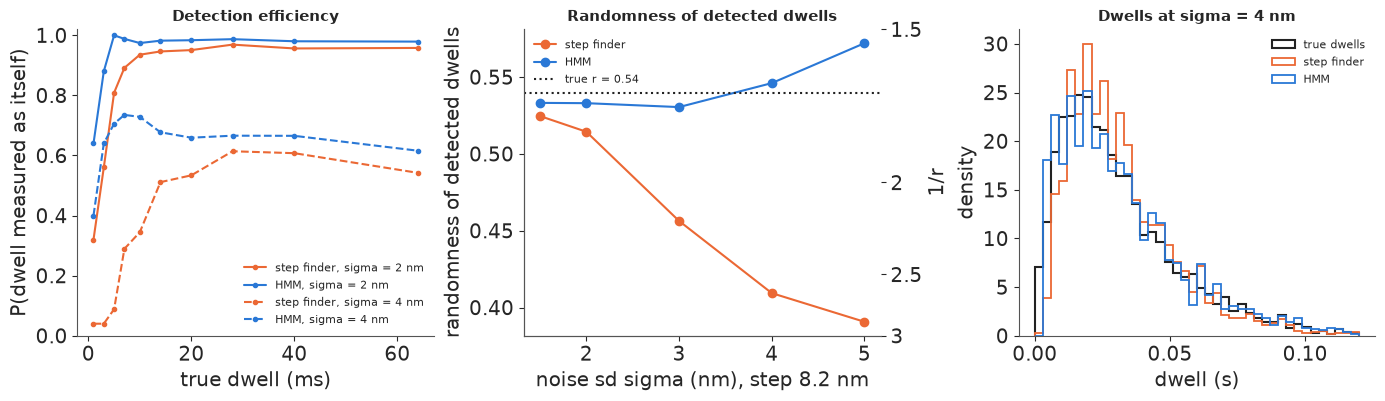

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
bins = np.array([0, 2, 4, 6, 8, 12, 16, 24, 32, 48, 80]) * 1e-3
mid = 0.5 * (bins[1:] + bins[:-1])
ax = axes[0]
for s, ls in [(2.0, "-"), (4.0, "--")]:
    for key, col in [("step finder", ORANGE), ("HMM", BLUE)]:
        eff = study[s][0][key]["eff"]
        ib = np.digitize(eff[:, 0], bins) - 1
        ax.plot(mid * 1e3, [eff[ib == b, 1].mean() for b in range(len(mid))], ls, color=col, marker="o", ms=3,
                label=f"{key}, sigma = {s:g} nm")
ax.set(xlabel="true dwell (ms)", ylabel="P(dwell measured as itself)", ylim=(0, 1.02),
       title="Detection efficiency")
ax.legend(fontsize=8)
ax = axes[1]
for key, col in [("step finder", ORANGE), ("HMM", BLUE)]:
    ax.plot(SIGMAS, [study[s][0][key]["r"] for s in SIGMAS], "o-", color=col, label=key)
ax.axhline(r_true, color=INK, ls=":", label=f"true r = {r_true:.2f}")
ax.set(xlabel="noise sd sigma (nm), step 8.2 nm", ylabel="randomness of detected dwells",
       title="Randomness of detected dwells")
ax2 = ax.twinx()
ax2.set_ylim(np.array(ax.get_ylim()))
ax2.set_yticks([1 / 1.5, 0.5, 1 / 2.5, 1 / 3])
ax2.set_yticklabels(["1.5", "2", "2.5", "3"])
ax2.set_ylabel("1/r")
ax.legend(fontsize=8)
ax = axes[2]
hb = np.linspace(0, 0.12, 41)
ax.hist(study[4.0][1], hb, density=True, histtype="step", color=INK, lw=1.5, label="true dwells")
for key, col in [("step finder", ORANGE), ("HMM", BLUE)]:
    ax.hist(study[4.0][0][key]["dwells"], hb, density=True, histtype="step", color=col, lw=1.3, label=key)
ax.set(xlabel="dwell (s)", ylabel="density", title="Dwells at sigma = 4 nm")
ax.legend(fontsize=8);

Left: the probability that a true dwell is measured as itself. Dwells shorter than a few samples
are lost by both methods, much more by the step finder, and at $\sigma = 4$ nm (steps two
noise-sds high) the step finder measures only about half of the dwells correctly even at 20-60 ms,
the HMM about two thirds. Middle: the consequence for the randomness parameter. Each missed step
replaces two dwells by their sum, and a sum of two dwells is *more regular* than either ($r$
halves), so as the noise grows the step finder's dwells look more and more clockwork-like: at
$\sigma = 4$ nm, $1/r$ suggests about 2.5 hidden steps where there are 2. The HMM's $r$ stays
within 0.03 of the truth at every noise level (it drifts slightly upwards at the highest noise),
because its missed and false steps roughly balance and it does not lose short dwells as
systematically. Right: the histograms at $\sigma = 4$ nm; the step finder's has lost its short
dwells and grown a tail of merged ones.

Correlated noise is the step finder's other weakness. With $\phi = 0.7$ the successive-difference
estimate $\mathrm{sd}(\Delta y)/\sqrt2 = \sigma\sqrt{1-\phi}$ underestimates the noise by ~45%,
the penalty is three times too small, and the printout above shows the flood of false steps that
follows. The HMM estimates $\phi$ and is not fooled.

Two lessons for real data. Dwell statistics are only as good as the detector; and the part of the
distribution that counts hidden steps (short dwells) is exactly the part a detector removes.

## 4 · Data: kinesin-1 under MINFLUX

MINFLUX localises a single fluorescent molecule by probing it with a doughnut-shaped beam at a few
positions around its current estimate and comparing photon counts; it needs only tens of photons
per position. Wolff, Scheiderer et al. (2023) used an interferometric MINFLUX microscope to track
a small dye attached to kinesin-1 at nanometre precision with sub-millisecond sampling, without a
bead pulling on the motor, at ATP concentrations up to physiological. They attached the dye at
different places: on the **stalk** (construct N356C, which moves 8 nm per ATP) and on one **head**
(T324C, K28C, E215C, which move 16 nm in two substeps). The public data contain their raw traces
and the tables their pipeline produced: for each detected step, its size, the dwell until the next
step, and plateau statistics. We use the stalk construct N356C at 10 µM and 1 mM ATP: its dwell is
one full chemical cycle.

In [8]:
data.describe("wolff2023_minflux_kinesin")
raw = np.load(data.path("wolff2023_minflux_kinesin"))
names = list(raw["cond_names"])
tab = {k: raw[k] for k in ["cond", "step_nm", "dwell_s", "end_of_trace", "hmm_state"]}
for i, c in enumerate(names):
    msk = tab["cond"] == i
    dw = tab["dwell_s"][msk]
    dw, st_ = dw[dw > 0], tab["step_nm"][msk]
    print(f"{c:17s} {int(tab['end_of_trace'][msk].sum()):4d} traces {int((st_ != 0).sum()):5d} steps, "
          f"median step {np.median(st_[st_ != 0]):5.1f} nm, dwells: mean {1e3 * dw.mean():5.1f} ms, "
          f"r = {dw.var() / dw.mean() ** 2:.2f}")

wolff2023_minflux_kinesin: NumPy .npz (open data.path(...) with np.load): kinesin-1 stepping on microtubules tracked with interferometric MINFLUX (a ~1 nm dye on a cysteine: N356C = coiled-coil stalk; T324C, K28C, E215C = motor head) at 10 uM, 100 uM or 1 mM ATP. Step table, one row per detected step of one trace: cond (index into cond_names / cond_construct / cond_atp_uM), step_nm (on-axis), offaxis_nm, dwell_s (time from this step to the next; 0 on the last two rows of a trace), plateau_sd_nm, photons, end_of_trace (1 on the last row of each trace), hmm_state (authors' step classes: 2 bound-to-bound, 3 bound-to-unbound, 4 unbound-to-bound, 5/6 rare, 0 not classified; not valid for N356C). Raw traces: trace_t_s, trace_x_nm, trace_photons concatenated, trace k is [trace_offset[k]:trace_offset[k+1]], trace_cond its condition name.
  source: Wolff & Scheiderer (2023), data and MATLAB scripts for 'MINFLUX dissects the unimpeded walking of kinesin-1' (Wolff, Scheiderer et al., Science 379:

Two things stand out before any modelling. The median detected step of the stalk construct (N356C)
is 6-8 nm, not 8.2: the table contains a good number of small steps. (The head constructs move 16
nm per step in two substeps, hence their larger medians.) And the pooled randomness is **above 1**
for most conditions. A single sequence of irreversible steps cannot give $r > 1$; heavy tails can
(pauses, merged dwells from missed steps, and molecules that walk at different speeds pooled
together). We look at the raw traces first.

30 raw traces; sampling interval (median): 10uM 1.21 ms, 1mM 0.62 ms
residuals around the step fit: sd 1.90 nm, lag-1 correlation 0.01 (pairs of samples averaged: -0.02)
step finder on the raw traces: 317 steps, median 6.6 nm, 40% smaller than 6 nm


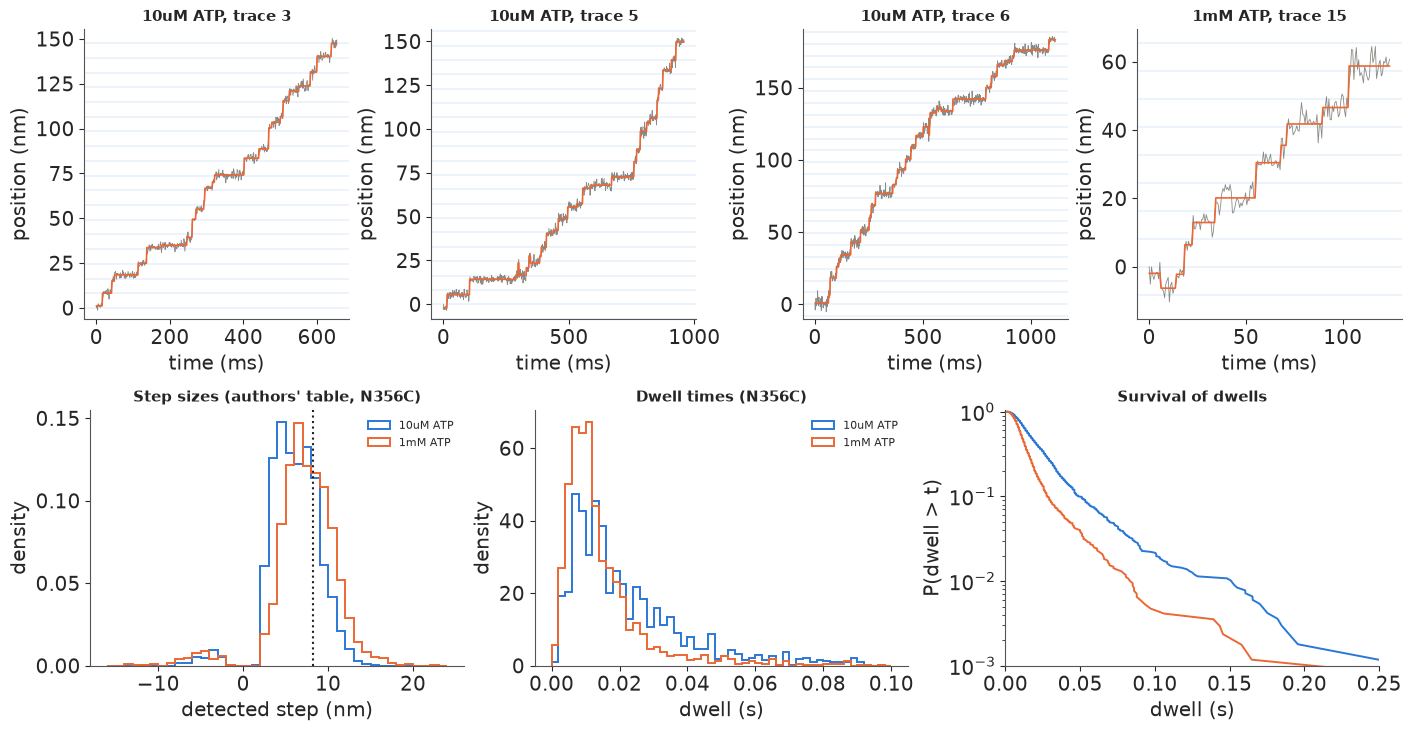

In [9]:
toff, tcond = raw["trace_offset"], raw["trace_cond"]
real = [(raw["trace_t_s"][toff[k]:toff[k + 1]], raw["trace_x_nm"][toff[k]:toff[k + 1]].astype(float))
        for k in range(len(tcond))]
show = [k for k in range(len(tcond)) if tcond[k] == "N356C_DOL1_10uM" and len(real[k][0]) > 400][:3]
show += [k for k in range(len(tcond)) if tcond[k] == "N356C_DOL1_1mM" and len(real[k][0]) > 190][:1]


def trace_stats(t, x):
    """Step-finder fit with the authors' penalty, residual sd and lag-1 correlation."""
    cps, fit = step_finder(x, 12 * (np.std(np.diff(x)) / np.sqrt(2)) ** 2)
    res = x - fit
    return cps, fit, res.std(), np.corrcoef(res[1:], res[:-1])[0, 1]


stats_real = {}
for k in range(len(tcond)):
    t, x = real[k]
    stats_real[k] = trace_stats(t, x)
    tb, xb = t[: len(t) // 2 * 2].reshape(-1, 2).mean(1), x[: len(x) // 2 * 2].reshape(-1, 2).mean(1)
    stats_real[k] += trace_stats(tb, xb)[2:]
sd_raw = np.median([v[2] for v in stats_real.values()])
ac_raw = np.median([v[3] for v in stats_real.values()])
ac_bin = np.median([v[5] for v in stats_real.values()])
dt_med = {c: np.median(np.concatenate([np.diff(real[k][0]) for k in range(len(tcond)) if tcond[k] == c]))
          for c in ["N356C_DOL1_10uM", "N356C_DOL1_1mM"]}
print(f"{len(real)} raw traces; sampling interval (median): "
      + ", ".join(f"{c.split('_')[-1]} {1e3 * v:.2f} ms" for c, v in dt_med.items()))
print(f"residuals around the step fit: sd {sd_raw:.2f} nm, lag-1 correlation {ac_raw:.2f} "
      f"(pairs of samples averaged: {ac_bin:.2f})")
all_steps = np.concatenate([np.diff(v[1])[np.diff(v[1]) != 0] for v in stats_real.values()])
print(f"step finder on the raw traces: {len(all_steps)} steps, median {np.median(all_steps):.1f} nm, "
      f"{np.mean(np.abs(all_steps) < 6):.0%} smaller than 6 nm")

fig = plt.figure(figsize=(14, 7.2))
top, bottom = fig.subfigures(2, 1, height_ratios=[1.1, 1])
axt = top.subplots(1, 4)
for ax, k in zip(axt, show):
    t, x = real[k]
    ax.plot(t * 1e3, x, color=GREY, lw=0.6)
    ax.plot(t * 1e3, stats_real[k][1], color=ORANGE, lw=1.2)
    for g in np.arange(-2, 40) * STEP:
        ax.axhline(g, color=BLUE, lw=0.3, alpha=0.4)
    ax.set_ylim(x.min() - 5, x.max() + 5)
    ax.set(xlabel="time (ms)", title=f"{tcond[k].split('_')[-1]} ATP, trace {k}", ylabel="position (nm)")
axb = bottom.subplots(1, 3)
ax = axb[0]
for c, col in [("N356C_DOL1_10uM", BLUE), ("N356C_DOL1_1mM", ORANGE)]:
    st_ = tab["step_nm"][tab["cond"] == names.index(c)]
    ax.hist(st_[st_ != 0], np.arange(-16, 24.5, 1), histtype="step", color=col, lw=1.4, density=True,
            label=c.split("_")[-1] + " ATP")
ax.axvline(STEP, color=INK, ls=":")
ax.set(xlabel="detected step (nm)", ylabel="density", title="Step sizes (authors' table, N356C)")
ax.legend(fontsize=8)
ax = axb[1]
hb = np.arange(0, 101, 2) * 1e-3
for c, col in [("N356C_DOL1_10uM", BLUE), ("N356C_DOL1_1mM", ORANGE)]:
    dw = tab["dwell_s"][(tab["cond"] == names.index(c)) & (tab["dwell_s"] > 0)]
    ax.hist(dw, hb, histtype="step", color=col, lw=1.4, density=True, label=c.split("_")[-1] + " ATP")
ax.set(xlabel="dwell (s)", ylabel="density", title="Dwell times (N356C)")
ax.legend(fontsize=8)
ax = axb[2]
for c, col in [("N356C_DOL1_10uM", BLUE), ("N356C_DOL1_1mM", ORANGE)]:
    dw = np.sort(tab["dwell_s"][(tab["cond"] == names.index(c)) & (tab["dwell_s"] > 0)])
    ax.semilogy(dw, 1 - np.arange(len(dw)) / len(dw), color=col, lw=1.4, label=c.split("_")[-1] + " ATP")
ax.set(xlabel="dwell (s)", ylabel="P(dwell > t)", xlim=(0, 0.25), ylim=(1e-3, 1.05),
       title="Survival of dwells");

Top: four raw traces of the stalk dye (grey) with the penalised step fit using the authors'
penalty (orange); the blue lines are an 8.2 nm grid for scale (the traces start at 0 by
construction, so the grid is not aligned with the lattice). The staircase is plain, 8 nm treads
with ~2 nm of noise, but so are the problems of section 2: the fit often splits a step into two
half-steps (40% of its steps are smaller than 6 nm) and places short treads during noisy
stretches. The residuals around the fit have an sd of about 1.9 nm and, unlike the simulation of
section 2, are essentially uncorrelated from sample to sample (lag-1 correlation 0.01). Bottom
left: the authors' detected steps peak near 8 nm but with a broad shoulder of 3-6 nm steps, the
same half-steps. Bottom middle: the dwell histograms rise from zero and peak at 6-12 ms, the
signature of more than one hidden step (or of a detector that cannot see short dwells - section 5
shows why the two look the same). Bottom right: on a log scale the survival curves are roughly
straight from ~20 to ~100 ms, an exponential tail, slower at 10 µM than at 1 mM, and with a few
very long dwells.

## 5 · How many hidden steps?

The model for the detected dwells of one condition has three parts.

1. **Chemistry**: $n$ sequential irreversible steps, a hypoexponential with rates $k_1 < k_2 <
   \dots < k_n$ (ordered, because the density is symmetric in them).
2. **Missed steps**: with probability $\varepsilon$ a detected dwell is two true dwells merged,
   whose density is the self-convolution $f * f$. For the hypoexponential it has a closed form
   with double poles, $f*f(t) = \sum_i c_i^2 k_i^2\, t\, e^{-k_i t} + \sum_{i \ne j} c_i c_j k_i
   k_j \frac{e^{-k_i t} - e^{-k_j t}}{k_j - k_i}$, and its survival function likewise.
3. **Dead time**: dwells shorter than $t_{\min}$ are unreliable (the MINFLUX sampling interval is
   0.6-1.2 ms and the authors' pipeline smooths over several samples), so we keep only dwells
   longer than $t_{\min}$ and condition on it: the likelihood of a dwell is $g(t) / G(t >
   t_{\min})$ with $g = (1 - \varepsilon) f + \varepsilon\, f * f$.

The formulas with $c_i = \prod_{j\ne i} k_j/(k_j - k_i)$ lose precision when two rates nearly
coincide. We sort the rates and keep neighbours at least 1% apart inside the likelihood (the
density changes by far less than that; a unit test below checks both pieces against simulation).
Priors: log-rates $\sim N(\log 100, 1.5)$, ordered; $\varepsilon \sim \text{Beta}(1, 9)$.

In [10]:
def spread_rates(k, n, rel_gap=0.01):
    """Sort the rates and keep neighbours at least rel_gap apart (numerical safety of the c_i)."""
    ks = pt.sort(k)
    out = [ks[0]]
    for i in range(1, n):
        out.append(pt.maximum(ks[i], out[-1] * (1 + rel_gap)))
    return pt.stack(out)


def hypo_coefs(k):
    n = k.shape[-1]
    eye = pt.eye(n)
    diff = k[None, :] - k[:, None]                               # [i, j] = k_j - k_i
    return pt.prod(pt.switch(eye > 0, 1.0, k[None, :] / pt.switch(eye > 0, 1.0, diff)), axis=-1)


def hypo_logpdf_logsf(t, k):
    """log density and log survival of the hypoexponential (distinct rates k), t of shape (N,)."""
    c, e = hypo_coefs(k), pt.exp(-t[:, None] * k[None, :])
    return (pt.log(pt.maximum((c * k * e).sum(-1), 1e-300)), pt.log(pt.maximum((c * e).sum(-1), 1e-300)))


def merged_logpdf_logsf(t, k):
    """log density and log survival of the sum of two independent hypoexponential dwells."""
    c, n = hypo_coefs(k), k.shape[0]
    kt = t[:, None] * k[None, :]
    e = pt.exp(-kt)
    f = (c**2 * k**2 * t[:, None] * e).sum(-1)
    S = (c**2 * (1 + kt) * e).sum(-1)
    ki, kj, off = k[:, None], k[None, :], 1 - pt.eye(n)
    w = off * c[:, None] * c[None, :] * ki * kj / pt.switch(off > 0, kj - ki, 1.0)
    ei, ej = e[:, :, None], e[:, None, :]
    f = f + (w[None] * (ei - ej)).sum((1, 2))
    S = S + (w[None] * (ei / ki[None] - ej / kj[None])).sum((1, 2))
    return pt.log(pt.maximum(f, 1e-300)), pt.log(pt.maximum(S, 1e-300))


def dwell_logp(t, k, eps, tmin):
    """Per-dwell log-likelihood: (1 - eps) f + eps f*f, truncated to t > tmin."""
    lf, _ = hypo_logpdf_logsf(t, k)
    lf2, _ = merged_logpdf_logsf(t, k)
    tm = pt.as_tensor(np.array([tmin]))
    _, lS = hypo_logpdf_logsf(tm, k)
    _, lS2 = merged_logpdf_logsf(tm, k)
    num = pt.logaddexp(pt.log1p(-eps) + lf, pt.log(eps) + lf2)
    return num - pt.logaddexp(pt.log1p(-eps) + lS[0], pt.log(eps) + lS2[0])


# unit test against simulation: density integrates to 1, survival matches Monte Carlo
kk, tt_ = pt.dvector("k"), pt.dvector("t")
check = pytensor.function([tt_, kk], [*hypo_logpdf_logsf(tt_, kk), *merged_logpdf_logsf(tt_, kk)])
tgrid = np.linspace(0, 0.5, 20001)[1:]
mc = rng.exponential(1 / np.array([60.0, 61.0, 400.0]), (200_000, 3)).sum(1)
mc2 = mc + rng.exponential(1 / np.array([60.0, 61.0, 400.0]), (200_000, 3)).sum(1)
lf, lS, lf2, lS2 = check(tgrid, np.array([60.0, 61.0, 400.0]))
i20 = np.searchsorted(tgrid, 0.02)
print(f"integral of f = {np.trapezoid(np.exp(lf), tgrid):.4f}, of f*f = {np.trapezoid(np.exp(lf2), tgrid):.4f}; "
      f"S(20 ms) = {np.exp(lS[i20]):.4f} vs MC {np.mean(mc > tgrid[i20]):.4f}; "
      f"merged S(20 ms) = {np.exp(lS2[i20]):.4f} vs MC {np.mean(mc2 > tgrid[i20]):.4f}")


def cond_dwells(cond, tmin):
    msk = (tab["cond"] == names.index(cond)) & (tab["dwell_s"] > tmin)
    return tab["dwell_s"][msk]


def fit_steps(cond, n, tmin, ordered=True, seed=RANDOM_SEED):
    """n-step hypoexponential + merged dwells + dead time; returns idata (with log_likelihood)."""
    t = cond_dwells(cond, tmin)
    with pm.Model():
        kw = {"transform": pm.distributions.transforms.ordered} if ordered else {}
        lk = pm.Normal("log_k", np.log(100.0), 1.5, shape=n, **kw)
        eps = pm.Beta("eps", 1.0, 9.0)
        pm.CustomDist("dwell", lk, eps, observed=t, signature="(n),()->()",
                      logp=lambda v, lk, eps: dwell_logp(v.ravel(), spread_rates(pt.exp(lk.reshape((-1,))[-n:]), n),
                                                         eps.reshape((-1,))[0], tmin).reshape(v.shape))
        t0 = time.time()
        idata = pm.sample(random_seed=seed, progressbar=False,
                          initvals={"log_k": np.log(np.geomspace(60, 600, n))} if ordered else None)
        el = time.time() - t0
        pm.compute_log_likelihood(idata, progressbar=False)
    idata.attrs["t_fit"] = el
    return idata

integral of f = 1.0000, of f*f = 1.0000; S(20 ms) = 0.7139 vs MC 0.7121; merged S(20 ms) = 0.9838 vs MC 0.9836


`pm.CustomDist` with `signature="(n),()->()"` gives one log-likelihood term per dwell, so `az.loo`
works directly (inside the logp the parameters arrive with a broadcast batch dimension;
`.reshape((-1,))[-n:]` takes the vector of rates back out). We fit $n = 1, \dots, 4$ to the 1 mM
dwells with $t_{\min} = 3$ ms.

In [11]:
C1MM, C10 = "N356C_DOL1_1mM", "N356C_DOL1_10uM"
loo_steps, rates_steps = {}, {}
for n in [1, 2, 3, 4]:
    idata = fit_steps(C1MM, n, 0.003)
    report(idata, ["log_k", "eps"], f"n = {n}", idata.attrs["t_fit"])
    rates_steps[n] = np.exp(idata.posterior["log_k"]).mean(("chain", "draw")).values
    loo = az.loo(idata, pointwise=True)
    loo.log_weights = None
    loo_steps[f"n = {n}"] = loo
    if n == 2:
        idata_n2 = idata
    else:
        del idata
print({n: np.round(r, 0).tolist() for n, r in rates_steps.items()})
cmp_steps = az.compare(loo_steps, round_to=1)
print(cmp_steps[["elpd", "elpd_diff", "dse", "p", "weight"]])

n = 1: 2 s, 0 divergences, max r_hat 1.005, min ESS 759


n = 2: 3 s, 0 divergences, max r_hat 1.004, min ESS 1200


n = 3: 3 s, 0 divergences, max r_hat 1.004, min ESS 1374


n = 4: 4 s, 4 divergences, max r_hat 1.005, min ESS 981


{1: [79.0], 2: [85.0, 385.0], 3: [87.0, 528.0, 718.0], 4: [87.0, 645.0, 836.0, 1265.0]}
         elpd  elpd_diff  dse    p  weight
n = 4  5544.0        0.0  0.0  3.2     1.0
n = 3  5539.8       -4.2  1.0  3.1     0.0
n = 2  5531.9      -12.1  2.8  2.7     0.0
n = 1  5513.5      -30.5  7.1  1.8     0.0


With $t_{\min} = 3$ ms the data ask for as many steps as we offer: every added step raises the
expected log predictive density, from one step to four by about 30 (several standard errors). The
rates tell the story: one slow step at ~87/s, and one to three extra steps at several hundred to
over a thousand per second. They add a combined delay of a few milliseconds - just the size of the
region below which section 3's detectors lose dwells. Some of these fits (and of those
below) report a handful of divergences, at most 6 of 4,000 draws; r_hat and ESS are fine, and we
note them rather than chase them because the conclusions rest on elpd differences of 20-30 or of
about zero.

**Label switching.** Before interpreting any of this, the ordering. Fit $n = 2$ without the
ordered transform: the likelihood (which sorts the rates internally) is identical, but now "rate
1" can be the slow or the fast one.

n = 2, unordered: 3 s, 0 divergences, max r_hat 1.532, min ESS 7
per-chain posterior means of log_k:
 [[4.45 5.96]
 [5.96 4.44]
 [5.94 4.45]
 [5.96 4.44]]


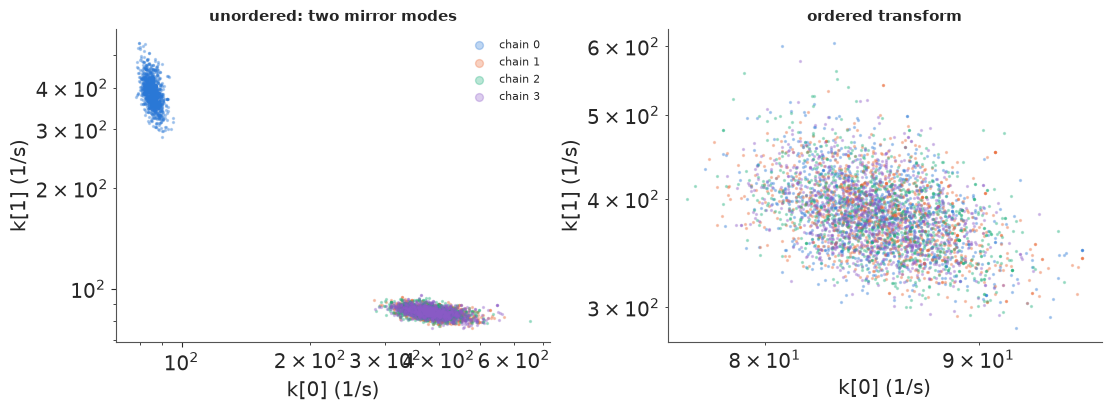

In [12]:
idata_un = fit_steps(C1MM, 2, 0.003, ordered=False)
report(idata_un, ["log_k"], "n = 2, unordered", idata_un.attrs["t_fit"])
print("per-chain posterior means of log_k:\n", idata_un.posterior["log_k"].mean("draw").values.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, idt, title in [(axes[0], idata_un, "unordered: two mirror modes"), (axes[1], idata_n2, "ordered transform")]:
    lk = idt.posterior["log_k"]
    for c, col in enumerate([BLUE, ORANGE, AQUA, PURPLE]):
        ax.scatter(np.exp(lk.sel(chain=c)[:, 0]), np.exp(lk.sel(chain=c)[:, 1]), s=2, alpha=0.3, color=col,
                   label=f"chain {c}")
    ax.set(xscale="log", yscale="log", xlabel="k[0] (1/s)", ylabel="k[1] (1/s)", title=title)
axes[0].legend(fontsize=8, markerscale=4);

Unordered, the chains sit in the two mirror-image modes (a slow rate labelled 0 or labelled 1),
and the r_hat printed above is far from 1 with no divergence to warn us. Nothing is wrong with the
fit - both modes are the same model - but every per-rate summary is meaningless. Ordering the
rates (right) removes the symmetry. With $n$ steps there are $n!$ modes, and ordering is the
cheapest fix; for a scheme whose steps are *not* exchangeable (for instance, one step depends on
ATP and the others do not, section 6) the data themselves break the symmetry.

**Is the evidence for extra steps real?** Section 1 showed that the shortest dwells carry that
evidence, and section 3 that detectors lose short dwells. So raise the dead time to 6 ms and ask
again, at both ATP concentrations: one step against four.

In [13]:
elpd_tmin = {}
for cond in [C1MM, C10]:
    for tmin in [0.003, 0.006]:
        if cond == C1MM and tmin == 0.003:
            elpd_tmin[(cond, tmin)] = {n: loo_steps[f"n = {n}"].elpd for n in [1, 4]}
            continue
        elpd_tmin[(cond, tmin)] = {}
        for n in [1, 4]:
            idata = fit_steps(cond, n, tmin)
            s = report(idata, ["log_k", "eps"], f"{cond.split('_')[-1]}, t > {1e3 * tmin:.0f} ms, n = {n}",
                       idata.attrs["t_fit"])
            elpd_tmin[(cond, tmin)][n] = az.loo(idata).elpd
            if n == 1:
                print(f"   one-step rate {np.exp(idata.posterior['log_k']).mean().item():.0f}/s")
            del idata
for (cond, tmin), v in elpd_tmin.items():
    print(f"{cond.split('_')[-1]:5s} ATP, dwells > {1e3 * tmin:.0f} ms: elpd(4 steps) - elpd(1 step) = "
          f"{v[4] - v[1]:.1f}")

1mM, t > 6 ms, n = 1: 2 s, 0 divergences, max r_hat 1.003, min ESS 1160


   one-step rate 87/s


1mM, t > 6 ms, n = 4: 5 s, 6 divergences, max r_hat 1.001, min ESS 1575


10uM, t > 3 ms, n = 1: 2 s, 4 divergences, max r_hat 1.008, min ESS 735


   one-step rate 47/s


10uM, t > 3 ms, n = 4: 6 s, 0 divergences, max r_hat 1.003, min ESS 1016


10uM, t > 6 ms, n = 1: 3 s, 0 divergences, max r_hat 1.007, min ESS 804


   one-step rate 50/s


10uM, t > 6 ms, n = 4: 5 s, 0 divergences, max r_hat 1.004, min ESS 1490


1mM   ATP, dwells > 3 ms: elpd(4 steps) - elpd(1 step) = 30.5
1mM   ATP, dwells > 6 ms: elpd(4 steps) - elpd(1 step) = -0.7
10uM  ATP, dwells > 3 ms: elpd(4 steps) - elpd(1 step) = 18.9
10uM  ATP, dwells > 6 ms: elpd(4 steps) - elpd(1 step) = -0.8


The evidence for extra steps is entirely in the dwells between 3 and 6 ms. Above 6 ms, one step
(plus merged dwells) fits as well as four, at both ATP concentrations; below it, four steps win by
20-30 units. There is a precise reason this cannot be settled from the histogram alone. A detector
that finds a dwell of length $t$ with probability $h(t) = 1 - e^{-t/\tau_d}$ turns an exponential
dwell $k e^{-kt}$ into

$$k e^{-kt}\,(1 - e^{-t/\tau_d}) \;\propto\; \frac{k\,k_d}{k_d - k}\left(e^{-kt} - e^{-k_d t}\right),
\qquad k_d = k + 1/\tau_d,$$

**exactly a two-step hypoexponential.** A dead time that fades out over a few milliseconds and a
hidden chemical step of a few milliseconds are the same function of $t$. The four-step fit is
describing the detector as much as the motor. Separating the two needs outside information: a
calibration of the detector on simulated traces with the real noise (section 3's efficiency curve,
done for this microscope and pipeline), a detector that does not lose short dwells, or
experimental handles that act on one and not the other - such as ATP.

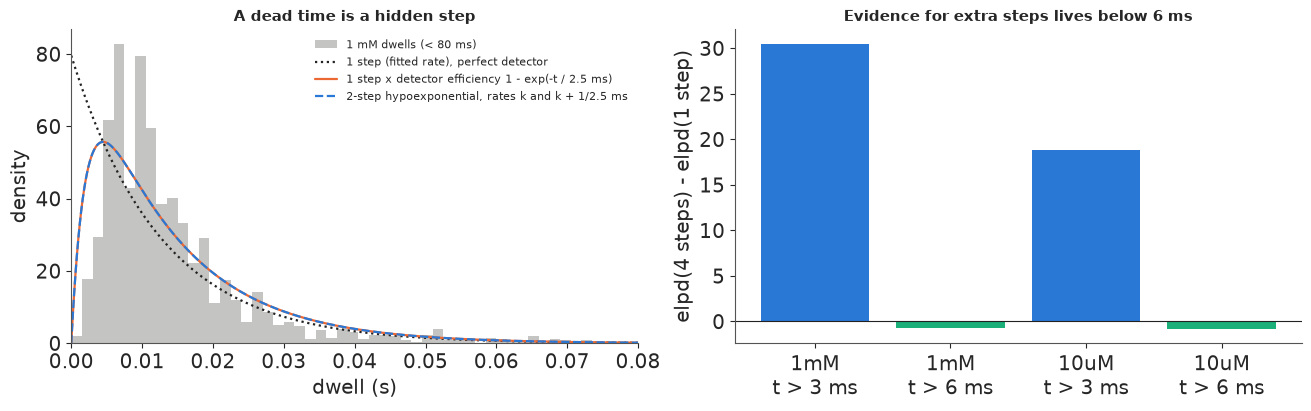

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
hb = np.arange(0, 81, 1.5) * 1e-3
t_obs = cond_dwells(C1MM, 0.0)
ax.hist(t_obs[t_obs < 0.08], hb, density=True, color=GREY, alpha=0.5, label="1 mM dwells (< 80 ms)")
tg = np.linspace(0.0, 0.08, 400)
k1s = rates_steps[1][0]
TAU_D = 0.0025                                   # detector fade-in time
kd = k1s + 1 / TAU_D
for lab, dens, col, ls in [
        ("1 step (fitted rate), perfect detector", k1s * np.exp(-k1s * tg), INK, ":"),
        ("1 step x detector efficiency 1 - exp(-t / 2.5 ms)", k1s * np.exp(-k1s * tg) * (1 - np.exp(-tg / TAU_D)),
         ORANGE, "-"),
        ("2-step hypoexponential, rates k and k + 1/2.5 ms", np_hypo_pdf(tg, [k1s, kd]), BLUE, "--")]:
    ax.plot(tg, dens / np.trapezoid(dens, tg), color=col, ls=ls, lw=1.6, label=lab)
ax.set(xlabel="dwell (s)", ylabel="density", title="A dead time is a hidden step", xlim=(0, 0.08))
ax.legend(fontsize=8)
ax = axes[1]
x = np.arange(4)
labels = [f"{c.split('_')[-1]}\nt > {1e3 * tm:.0f} ms" for (c, tm) in elpd_tmin]
ax.bar(x, [v[4] - v[1] for v in elpd_tmin.values()], color=[BLUE, AQUA, BLUE, AQUA])
ax.set_xticks(x, labels)
ax.axhline(0, color=INK, lw=0.8)
ax.set(ylabel="elpd(4 steps) - elpd(1 step)", title="Evidence for extra steps lives below 6 ms");

Left: the 1 mM histogram, a single exponential at the fitted rate (dotted), the same exponential
multiplied by a detector efficiency that fades in over 2.5 ms (orange), and a two-step
hypoexponential with rates $k$ and $k + 1/2.5\text{ ms}$ (dashed): the last two are the same
curve. Right: the LOO evidence for four steps over one, for each ATP concentration and dead time.

So what can the MINFLUX stalk dwells tell us honestly? Not the number of fast hidden steps; that
would need the calibration of the pipeline. What survives any dead time is the **slow,
rate-limiting part** of the cycle, and its ATP dependence: the one-step rates above 6 ms are ~50/s
at 10 µM and ~87/s at 1 mM. The pooled $r > 1$ of section 4 is also still unexplained. Both are
for the next section.

## 6 · ATP titration: a Michaelis-Menten cycle, and molecules that differ

The simplest chemical cycle with an ATP-dependent step: ATP binds with rate
$k_{\text{on}}[\text{ATP}]$, then the rest of the cycle (hydrolysis, the head stepping, product
release) takes an ATP-independent exponential time with rate $k_{\text{cat}}$. The dwell is
hypoexponential with rates $(k_{\text{on}}[\text{ATP}], k_{\text{cat}})$ and mean

$$\langle\tau\rangle = \frac{1}{k_{\text{cat}}} + \frac{1}{k_{\text{on}}[\text{ATP}]}, \qquad
v = \frac{d}{\langle\tau\rangle} = \frac{d\,k_{\text{cat}}\,[\text{ATP}]}{K_M + [\text{ATP}]},
\quad K_M = \frac{k_{\text{cat}}}{k_{\text{on}}},$$

the Michaelis-Menten law for the speed. The two concentrations now **break the label symmetry**:
only one of the two rates may change with ATP, and which one is identified. We fit both conditions
jointly (dwells > 3 ms, with merged dwells) in three versions:

- **A, identical molecules**: every dwell from the same two-rate cycle;
- **B, molecules that differ**: each traced molecule $j$ runs its whole cycle at speed $s_j =
  e^{\tau z_j}$ ($f_j(t) = s_j f(s_j t)$, and the dead-time normalisation per molecule), with $z_j
  \sim N(0, 1)$ **centred within each ATP concentration**, so the speed variation cannot mimic the
  ATP effect;
- **C, molecules that differ, uncentred**: the same without the centring.

Each trace is one molecule observed at one ATP concentration (289 traces with dwells > 3 ms).

In [15]:
TMIN = 0.003
rows = []
for ci, c in enumerate([C10, C1MM]):
    msk = tab["cond"] == names.index(c)
    dw, eot = tab["dwell_s"][msk], tab["end_of_trace"][msk]
    trace_id = np.r_[0, np.cumsum(eot)[:-1]] + 10_000 * ci
    keep = dw > TMIN
    rows.append((dw[keep], trace_id[keep], np.full(keep.sum(), ci)))
t_all = np.concatenate([r[0] for r in rows])
c_all = np.concatenate([r[2] for r in rows])
traces_u, tr_all = np.unique(np.concatenate([r[1] for r in rows]), return_inverse=True)
tr_cond = np.array([c_all[tr_all == j][0] for j in range(len(traces_u))])
ATP = np.array([10.0, 1000.0])
print(f"{len(t_all)} dwells from {len(traces_u)} molecules "
      f"({np.bincount(tr_cond)[0]} at 10 uM, {np.bincount(tr_cond)[1]} at 1 mM)")


def fit_atp(version, seed=RANDOM_SEED):
    coords = {"dwell": np.arange(len(t_all)), "molecule": np.arange(len(traces_u))}
    with pm.Model(coords=coords):
        log_kon = pm.Normal("log_kon", np.log(5.0), 1.5)        # per uM per s
        log_kcat = pm.Normal("log_kcat", np.log(100.0), 1.5)
        eps = pm.Beta("eps", 1.0, 9.0)
        pm.Deterministic("KM", pt.exp(log_kcat - log_kon))
        if version == "A":
            s = pt.ones(len(t_all))
        else:
            tau = pm.HalfNormal("tau", 0.5)
            z = pm.Normal("z", 0.0, 1.0, dims="molecule")
            if version == "B":
                for cc in range(2):
                    idx = np.where(tr_cond == cc)[0]
                    z = pt.set_subtensor(z[idx], z[idx] - z[idx].mean())
            s = pt.exp(tau * z)[tr_all]
        parts = []
        for ci in range(2):
            sel = np.where(c_all == ci)[0]
            k = spread_rates(pt.stack([pt.exp(log_kon) * ATP[ci], pt.exp(log_kcat)]), 2)
            ss = s[sel]
            lf, _ = hypo_logpdf_logsf(t_all[sel] * ss, k)
            lf2, _ = merged_logpdf_logsf(t_all[sel] * ss, k)
            _, lS = hypo_logpdf_logsf(TMIN * ss, k)
            _, lS2 = merged_logpdf_logsf(TMIN * ss, k)
            num = pt.logaddexp(pt.log1p(-eps) + lf, pt.log(eps) + lf2)
            parts.append(num - pt.logaddexp(pt.log1p(-eps) + lS, pt.log(eps) + lS2) + pt.log(ss))
        ll = pt.concatenate(parts)
        order = np.argsort(np.concatenate([np.where(c_all == ci)[0] for ci in range(2)]))
        ll = pm.Deterministic("ll", ll[order], dims="dwell")
        pm.Potential("dwell_lik", ll.sum())
        t0 = time.time()
        idata = pm.sample(random_seed=seed, progressbar=False, target_accept=0.9)
        el = time.time() - t0
    ll_draws = idata.posterior["ll"].values
    del idata.posterior["ll"]
    idata["log_likelihood"] = xr.Dataset({"dwell": (("chain", "draw", "obs"), ll_draws)})
    idata.attrs["t_fit"] = el
    return idata


fits_atp, loo_atp = {}, {}
for v in ["A", "B", "C"]:
    fits_atp[v] = fit_atp(v)
    names_v = ["log_kon", "log_kcat", "eps"] + ([] if v == "A" else ["tau"])
    s = report(fits_atp[v], names_v, f"version {v}", fits_atp[v].attrs["t_fit"])
    p = fits_atp[v].posterior
    print(f"   k_on = {np.exp(p['log_kon']).mean().item():.1f} /uM/s, k_cat = {np.exp(p['log_kcat']).mean().item():.0f} /s, "
          f"K_M = {p['KM'].median().item():.1f} uM [{p['KM'].quantile(0.055).item():.1f}, {p['KM'].quantile(0.945).item():.1f}], "
          f"eps = {p['eps'].mean().item():.3f}" + ("" if v == "A" else f", tau = {p['tau'].mean().item():.2f}"))
    loo = az.loo(fits_atp[v], pointwise=True)
    loo.log_weights = None
    loo_atp[v] = loo
    print(f"   Pareto k > 0.7 for {int((loo.pareto_k > 0.7).sum())} of {len(t_all)} dwells")
    del fits_atp[v]["log_likelihood"]
print(az.compare(loo_atp, round_to=1)[["elpd", "elpd_diff", "dse", "p", "weight"]])

3296 dwells from 289 molecules (154 at 10 uM, 135 at 1 mM)


version A: 12 s, 0 divergences, max r_hat 1.003, min ESS 1243
   k_on = 15.4 /uM/s, k_cat = 69 /s, K_M = 4.5 uM [3.8, 5.5], eps = 0.051


   Pareto k > 0.7 for 0 of 3296 dwells


version B: 20 s, 0 divergences, max r_hat 1.002, min ESS 1031
   k_on = 9.1 /uM/s, k_cat = 93 /s, K_M = 10.4 uM [8.5, 12.1], eps = 0.109, tau = 0.31


   Pareto k > 0.7 for 14 of 3296 dwells


version C: 20 s, 0 divergences, max r_hat 1.002, min ESS 842
   k_on = 19.7 /uM/s, k_cat = 72 /s, K_M = 3.7 uM [2.8, 4.9], eps = 0.067, tau = 0.33


   Pareto k > 0.7 for 8 of 3296 dwells
      elpd  elpd_diff   dse      p  weight
C  10203.6        0.0   0.0  181.8     0.7
B  10185.3      -18.3   7.4  197.1     0.1
A  10090.7     -112.8  21.3    4.5     0.2


All three samplers are clean (no divergences, r_hat ≤ 1.01). The estimates are not.

- **A** (identical molecules) gives $K_M \approx 4.5$ µM, but LOO rejects it decisively: it is
  ~110 units of elpd behind the others. Molecule-to-molecule variation is real and large: B and C
  both estimate a spread of speeds $\tau \approx 0.3$ (a molecule one sd faster than average walks
  ~35% faster). Pooling such molecules is a large part of what pushed the randomness of section 4
  above 1.
- **B** (variation centred within each ATP concentration) attributes the whole difference between
  the concentrations to the chemistry: $k_{\text{on}} \approx 9$/µM/s, $k_{\text{cat}} \approx
  93$/s, $K_M \approx 10$ µM. At 10 µM its two rates (~91 and ~93/s) are almost equal - the one
  case where the hypoexponential formula needs the 1% spacing guard of section 5.
- **C** (uncentred) lets the average molecule differ between the two concentrations, so part of
  the ATP effect can be carried by the molecules instead of the chemistry. Its $K_M \approx 4$ µM
  is less than half of B's, and **LOO prefers C** by ~18 ± 7.

Why LOO prefers the model that confounds its main question: each molecule was watched at one ATP
concentration only, so "these molecules are slow" and "10 µM ATP slows every molecule" make the
same prediction for the next dwell of a molecule already observed, and C has more freedom to fit
the two groups. LOO scores predictions of dwells, not causal attributions; the choice between B
and C is a design assumption (molecules drawn from the same population at both concentrations,
which randomisation of samples would justify) and not a question the data can settle. With a few
dozen dwells per molecule, the Pareto-k diagnostics are also flagged for some dwells in B and C
(counts above), so the LOO differences between them are approximate. What would settle it is a
design in which the **same molecules** are observed at more than one ATP concentration (buffer
exchange), or more concentrations.

N356C_DOL1_10uM: speed 241 nm/s (displacement/time), 330 nm/s (8.2 nm / mean dwell), mean detected step 6.0 nm
N356C_DOL1_1mM: speed 468 nm/s (displacement/time), 529 nm/s (8.2 nm / mean dwell), mean detected step 7.3 nm
version A: predicted 8.2 nm cycle speed 391 nm/s at 10 uM, 565 nm/s at 1000 uM
version B: predicted 8.2 nm cycle speed 376 nm/s at 10 uM, 755 nm/s at 1000 uM
version C: predicted 8.2 nm cycle speed 431 nm/s at 10 uM, 586 nm/s at 1000 uM


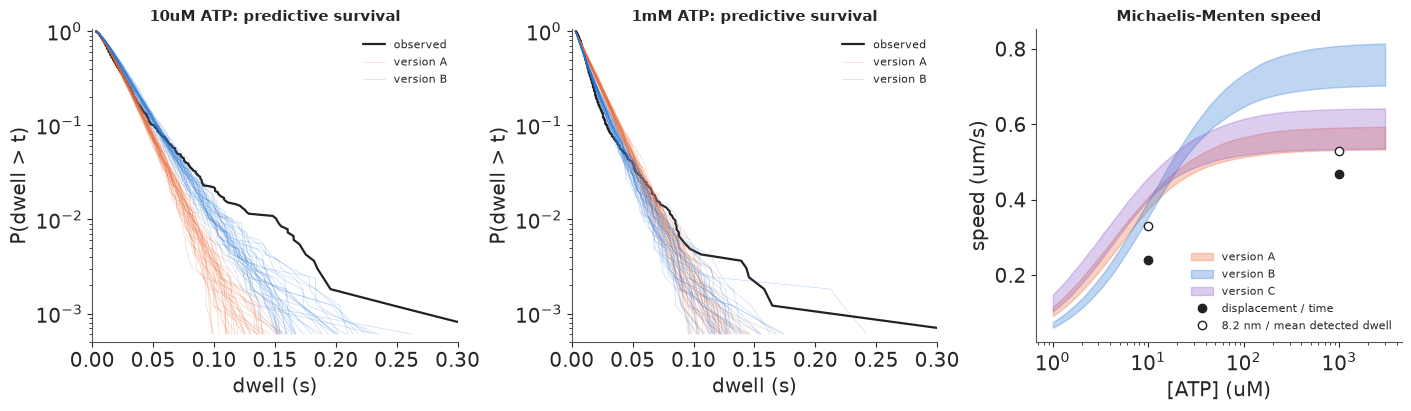

In [16]:
def ppc_dwells(idata, version, n_draws=200, seed=5):
    """Simulate detected dwells (with merging and dead time) from the posterior, per condition."""
    rs = np.random.default_rng(seed)
    p = az.extract(idata, var_names=["log_kon", "log_kcat", "eps"] + ([] if version == "A" else ["tau", "z"]),
                   num_samples=n_draws, random_seed=seed)
    sims_ = {0: [], 1: []}
    for i in range(n_draws):
        kon, kcat, eps = np.exp(p["log_kon"].values[i]), np.exp(p["log_kcat"].values[i]), p["eps"].values[i]
        if version == "A":
            sp = np.ones(len(traces_u))
        else:
            z = p["z"].values[:, i].copy()
            if version == "B":
                for cc in range(2):
                    z[tr_cond == cc] -= z[tr_cond == cc].mean()
            sp = np.exp(p["tau"].values[i] * z)
        for ci in range(2):
            n_obs = int((c_all == ci).sum())
            mol = rs.choice(np.where(tr_cond == ci)[0], 3 * n_obs)
            k = np.array([kon * ATP[ci], kcat])[None, :] * sp[mol][:, None]
            d1 = rs.exponential(1 / k).sum(1)
            d2 = d1 + rs.exponential(1 / k).sum(1)
            dd = np.where(rs.random(len(d1)) < eps, d2, d1)
            sims_[ci].append(dd[dd > TMIN][:n_obs])
    return sims_


ppc = {v: ppc_dwells(fits_atp[v], v) for v in ["A", "B"]}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ci, (c, ax) in enumerate(zip([C10, C1MM], axes[:2])):
    obs = np.sort(t_all[c_all == ci])
    ax.semilogy(obs, 1 - np.arange(len(obs)) / len(obs), color=INK, lw=1.6, label="observed")
    for v, col in [("A", ORANGE), ("B", BLUE)]:
        for j, dd in enumerate(ppc[v][ci][:40]):
            dd = np.sort(dd)
            ax.semilogy(dd, 1 - np.arange(len(dd)) / len(dd), color=col, lw=0.5, alpha=0.25,
                        label=f"version {v}" if j == 0 else None)
    ax.set(xlim=(0, 0.3), ylim=(5e-4, 1.05), xlabel="dwell (s)", ylabel="P(dwell > t)",
           title=f"{c.split('_')[-1]} ATP: predictive survival")
    ax.legend(fontsize=8)
ax = axes[2]
cgrid = np.geomspace(1, 3000, 100)
for v, col in [("A", ORANGE), ("B", BLUE), ("C", PURPLE)]:
    p = az.extract(fits_atp[v], var_names=["log_kon", "log_kcat"], num_samples=400, random_seed=1)
    kon, kcat = np.exp(p["log_kon"].values), np.exp(p["log_kcat"].values)
    vel = STEP * 1e-3 / (1 / kcat[:, None] + 1 / (kon[:, None] * cgrid[None, :]))     # um/s
    lo, hi = np.quantile(vel, [0.055, 0.945], axis=0)
    ax.fill_between(cgrid, lo, hi, color=col, alpha=0.3, label=f"version {v}")
speed_direct = {}
for ci, c in enumerate([C10, C1MM]):
    msk = tab["cond"] == names.index(c)
    st_, dw_, tid = tab["step_nm"][msk], tab["dwell_s"][msk], np.cumsum(np.r_[0, tab["end_of_trace"][msk][:-1]])
    disp = tim = 0.0
    for j in np.unique(tid):
        stj, dwj = st_[tid == j], dw_[tid == j]
        dwj = dwj[dwj > 0]
        disp += stj[1:len(dwj) + 1].sum()                 # displacement from the first to the last step
        tim += dwj.sum()
    speed_direct[c] = disp / tim * 1e-3
    ax.plot(ATP[ci], speed_direct[c], "o", color=INK, ms=6, label="displacement / time" if ci == 0 else None)
    ax.plot(ATP[ci], STEP * 1e-3 / dw_[dw_ > 0].mean(), "o", mfc="white", color=INK, ms=6,
            label="8.2 nm / mean detected dwell" if ci == 0 else None)
    print(f"{c}: speed {1e3 * speed_direct[c]:.0f} nm/s (displacement/time), "
          f"{8.2 / dw_[dw_ > 0].mean():.0f} nm/s (8.2 nm / mean dwell), mean detected step {st_[st_ != 0].mean():.1f} nm")
for v in ["A", "B", "C"]:
    p = fits_atp[v].posterior
    kon, kcat = np.exp(p["log_kon"]).mean().item(), np.exp(p["log_kcat"]).mean().item()
    print(f"version {v}: predicted 8.2 nm cycle speed " + ", ".join(
        f"{8.2 / (1 / kcat + 1 / (kon * a)):.0f} nm/s at {a:g} uM" for a in ATP))
ax.set(xscale="log", xlabel="[ATP] (uM)", ylabel="speed (um/s)", title="Michaelis-Menten speed")
ax.legend(fontsize=8);

Left and middle: survival curves of the dwells (> 3 ms) with 40 posterior predictive replicates of
A (orange) and B (blue). With identical molecules the predicted tail at 10 µM falls far too fast;
molecule-to-molecule variation fixes most of it. Neither reproduces the very long dwells of the
last few percent (pauses, or runs of missed steps). Right: the Michaelis-Menten speed curves $v =
8.2\text{ nm}/\langle\tau\rangle$ implied by each version (89% bands). The filled dots are the
speeds measured directly as displacement over time from the authors' step tables, the open dots
8.2 nm divided by the mean detected dwell.

The curves lie **above** the measured speeds, for two reasons we can see. First, the dwell tables
count too many steps: the mean detected step of the stalk construct is 6.0 nm at 10 µM and 7.3 nm
at 1 mM (printed above), so many 8.2 nm steps were split into two detected steps with two shorter
dwells - the false steps of section 3. That alone puts the open dots above the filled ones by the
factor 8.2 nm / mean detected step (1.37 and 1.13). Second, the kinetic model describes the
*shape* of the bulk of the dwell distribution and not the rare very long dwells, which carry a
large share of the total walking time. So the absolute rates here are biased upwards. The
**ratio** of the speeds at the two concentrations is more robust: the measured speed roughly
doubles from 10 µM to 1 mM (241 to 468 nm/s), which version B reproduces (376 to 755 nm/s) and A
and C, which put part of the ATP effect elsewhere, underpredict (factors of about 1.4).

## Summary

- A processive motor's position is a staircase; its chemistry is hidden in the dwells. A sequence
  of $n$ irreversible waits gives a **hypoexponential** dwell with randomness $1/n \le r \le 1$,
  so $1/r$ bounds the number of rate-limiting steps from below, and the rates' order is not
  identified (**label switching**; order them) (section 1).
- **Step detection** is part of the model. A penalised least-squares step finder loses short
  dwells, splits steps, and floods with false steps when the noise is correlated; a **lattice
  HMM** with hidden chemical phases, back steps and AR(1) noise, marginalised by a forward
  algorithm in `scan`, recovers step size and noise almost exactly and gives better dwells.
  Nutpie's start jitter sent chains into a noise-absorbing mode; common starting values fixed it
  (section 2).
- **Missed steps merge dwells and make them look regular** ($r$ falls, $1/r$ over-counts hidden
  steps); false steps do the opposite. The short dwells that count hidden steps are the ones
  detectors lose (section 3).
- On the MINFLUX kinesin data, LOO over the number of hidden steps prefers **four** steps - but
  the evidence lives entirely in dwells of 3-6 ms and vanishes above 6 ms. A detector efficiency
  $1 - e^{-t/\tau_d}$ is **mathematically identical** to one more hidden step: the dwell histogram
  alone cannot count fast steps below the dead time (section 5).
- The rate-limiting part of the cycle and its ATP dependence survive. A joint ATP model with
  $k_{\text{on}}[\text{ATP}]$ in series with an ATP-independent step needs **molecule-to-molecule
  variation** (~30% sd in speed, the source of $r > 1$). Whether that variation may differ between
  concentrations changes $K_M$ by a factor of two, LOO prefers the confounded version, and only
  the design (same molecule at several [ATP]) can settle it. Split steps in the dwell tables bias
  all dwell-based rates upwards relative to the directly measured speed (section 6).

## Try it yourself

1. **Where does ATP bind?** The head-labelled constructs (T324C, K28C, E215C, at 10 µM, 100 µM and
   1 mM) resolve each 16 nm head step into two ~8 nm substeps, and the authors' `hmm_state` column
   marks the dwell between them (the head unbound, `3` followed by `4`) and the dwells with the
   head bound (`2` or `4`). Fit the unbound and bound dwells jointly across the three
   concentrations with an ATP-dependent step placed either in the one-head-bound or in the
   two-head-bound phase, compare the two placements by LOO, and let the three labelling sites
   share their rates hierarchically.
2. **Calibrate the detector.** Simulate MINFLUX-like traces with the noise measured in section 4
   (sd ~1.9 nm, nearly uncorrelated), run the authors' criterion on them, estimate the detection efficiency
   $h(t)$ as in section 3, and put it into the dwell likelihood ($f(t)h(t)$, normalised). With $h$
   fixed, how many hidden steps does the 1 mM stalk data support?
3. **The HMM on real traces.** Fit the lattice HMM of section 2 to the raw N356C traces (average
   pairs of samples first, keep traces shorter than ~600 samples to bound the `scan`). With a free
   step size the posterior is multimodal: chains settle near 8.2 nm or on a finer lattice that
   explains each step as smaller steps. Which does LOO prefer, what does a prior at the tubulin
   spacing do, and do the fitted rates agree with section 6?